1. Realiza un análisis de calidad de datos, revisando aspectos básicos y selecciona un primer conjunto de variables a eliminar. Luego de ello, realiza un análisis exploratorio inicial considerando gráficos de distribuciones de las diferentes variables, y concluye al respecto. Si observas algo raro respecto a los tipos de variables debes proponer algún tratamiento.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Carga de datos
df = pd.read_excel('imdb_anime.xlsx')

print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (45717, 13)


,Title,Genre,User Rating,Number of Votes,Runtime,Year,Summary,Stars,Certificate,Metascore,Gross,Episode,Episode Title
0,One Piece,"Animation, Action, Adventure",8.9,187689,24 min,(1999– ),Follows the adventures of Monkey D. Luffy and ...,"Mayumi Tanaka,Laurent Vernin,Akemi Okamura,Ton...",TV-14,NaN,187689,0,NaN
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,"Animation, Action, Adventure",7.4,28895,99 min,-2023,The film follows the Turtle brothers as they w...,NaN,PG,74,28895,0,NaN
2,The Super Mario Bros. Movie,"Animation, Adventure, Comedy",7.1,189108,92 min,-2023,A plumber named Mario travels through an under...,NaN,PG,46,189108,0,NaN
3,Attack on Titan,"Animation, Action, Adventure",9.1,434457,24 min,(2013–2023),After his hometown is destroyed and his mother...,"Josh Grelle,Bryce Papenbrook,Yûki Kaji,Yui Ish...",TV-MA,NaN,434457,0,NaN
4,Jujutsu Kaisen,"Animation, Action, Adventure",8.5,82909,24 min,(2020– ),A boy swallows a cursed talisman - the finger ...,"Junya Enoki,Yûichi Nakamura,Adam McArthur,Yuma...",TV-MA,NaN,82909,0,NaN


In [2]:
# Información general
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 45717 entries, 0 to 45716
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            45717 non-null  object
 1   Genre            45717 non-null  str   
 2   User Rating      25009 non-null  object
 3   Number of Votes  25009 non-null  object
 4   Runtime          32549 non-null  str   
 5   Year             45591 non-null  object
 6   Summary          23547 non-null  str   
 7   Stars            13676 non-null  str   
 8   Certificate      28694 non-null  object
 9   Metascore        341 non-null    object
 10  Gross            25009 non-null  object
 11  Episode          45717 non-null  object
 12  Episode Title    34910 non-null  object
dtypes: object(9), str(4)
memory usage: 4.5+ MB


In [8]:
# Distribuciones de variables numéricas clave
# Primero convertimos las que están como texto
df_base['User Rating'] = pd.to_numeric(df_base['User Rating'], errors='coerce')
df_base['Number of Votes'] = pd.to_numeric(df_base['Number of Votes'], errors='coerce')
df_base['Gross'] = pd.to_numeric(df_base['Gross'], errors='coerce')

In [7]:
# Filtro mínimo: solo registros con User Rating Y Number of Votes
df_base = df[
    df['User Rating'].notna() &
    df['Number of Votes'].notna()
].copy()

print(f'Dataset original: {len(df)} filas')
print(f'Con User Rating y Number of Votes: {len(df_base)} filas')
print(f'Descartados: {len(df) - len(df_base)} filas')
print()
print('Distribución de Episode en este subset:')
print(df_base['Episode'].value_counts())
print()
print('Nulos restantes:')
print(df_base.isnull().sum())

Dataset original: 45717 filas
Con User Rating y Number of Votes: 25009 filas
Descartados: 20708 filas

Distribución de Episode en este subset:
Episode
1          17255
0           7753
Episode        1
Name: count, dtype: int64

Nulos restantes:
Title                  0
Genre                  0
User Rating            0
Number of Votes        0
Runtime             5227
Year                   0
Summary             4296
Stars              16950
Certificate         5464
Metascore          24668
Gross                  0
Episode                0
Episode Title       7753
dtype: int64


In [10]:
# ¿Los episodios (Episode=1) tienen Title del anime?
ep1 = df_base[df_base['Episode'] == '1']
ep0 = df_base[df_base['Episode'] == '0']

print(f'Episodios (Episode=1): {len(ep1)}')
print(f'Con Title: {ep1["Title"].notna().sum()}')
print(f'Sin Title: {ep1["Title"].isna().sum()}')
print()
print('Ejemplo de títulos en episodios:')
print(ep1['Title'].head(10).tolist())
print()
print('Ejemplo de Episode Title en episodios:')
print(ep1['Episode Title'].head(10).tolist())

Episodios (Episode=1): 0
Con Title: 0
Sin Title: 0

Ejemplo de títulos en episodios:
[]

Ejemplo de Episode Title en episodios:
[]


In [11]:
print('Valores únicos de Episode en df_base:')
print(df_base['Episode'].value_counts())
print()
print('Tipo de dato:', df_base['Episode'].dtype)
print()
print('Primeros valores:')
print(df_base['Episode'].head(10).tolist())

Valores únicos de Episode en df_base:
Episode
1          17255
0           7753
Episode        1
Name: count, dtype: int64

Tipo de dato: object

Primeros valores:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
# Ver la fila con valor 'Episode' en la columna Episode
print('Fila problemática:')
print(df_base[df_base['Episode'] == 'Episode'])
print()

# Convertir Episode a numérico correctamente
df_base['Episode'] = pd.to_numeric(df_base['Episode'], errors='coerce')

print('Valores únicos después de convertir:')
print(df_base['Episode'].value_counts(dropna=False))

Fila problemática:
     Title  Genre  User Rating  Number of Votes  Runtime  Year  Summary  \
840  Title  Genre          NaN              NaN  Runtime  Year  Summary   

     Stars  Certificate  Metascore  Gross  Episode  Episode Title  
840  Stars  Certificate  Metascore    NaN  Episode  Episode Title  

Valores únicos después de convertir:
Episode
1.0    17255
0.0     7753
NaN        1
Name: count, dtype: int64


In [13]:
# Eliminar la fila con header duplicado
df_base = df_base.dropna(subset=['Episode'])
df_base['Episode'] = df_base['Episode'].astype(int)

print(f'Filas después de limpiar: {len(df_base)}')
print(f'Valores de Episode: {df_base["Episode"].value_counts().to_dict()}')

Filas después de limpiar: 25008
Valores de Episode: {1: 17255, 0: 7753}


In [14]:
# ¿Los episodios (Episode=1) tienen Title del anime?
ep1 = df_base[df_base['Episode'] == 1]
ep0 = df_base[df_base['Episode'] == 0]

print(f'Episodios (Episode=1): {len(ep1)}')
print(f'Series/películas (Episode=0): {len(ep0)}')
print()
print(f'Episodios con Title: {ep1["Title"].notna().sum()}')
print()
print('Ejemplo de títulos en episodios:')
print(ep1[['Title', 'Episode Title']].head(5).to_string())

Episodios (Episode=1): 17255
Series/películas (Episode=0): 7753

Episodios con Title: 17255

Ejemplo de títulos en episodios:
                   Title                                    Episode Title
10803  A.D. Police Files                   A.D. Police File 2: The Ripper
10804  A.D. Police Files  AD Police Files 3: The Man Who Bites His Tongue
10805         Dirty Pair         Nani yokore! tama noo hada ga dorondoron
10806         Dirty Pair    Kokohore nyannyan kahou wa saigo ni yattekuru
10807         Dirty Pair             Yarukkyaanai! koha onna no kibakuzai


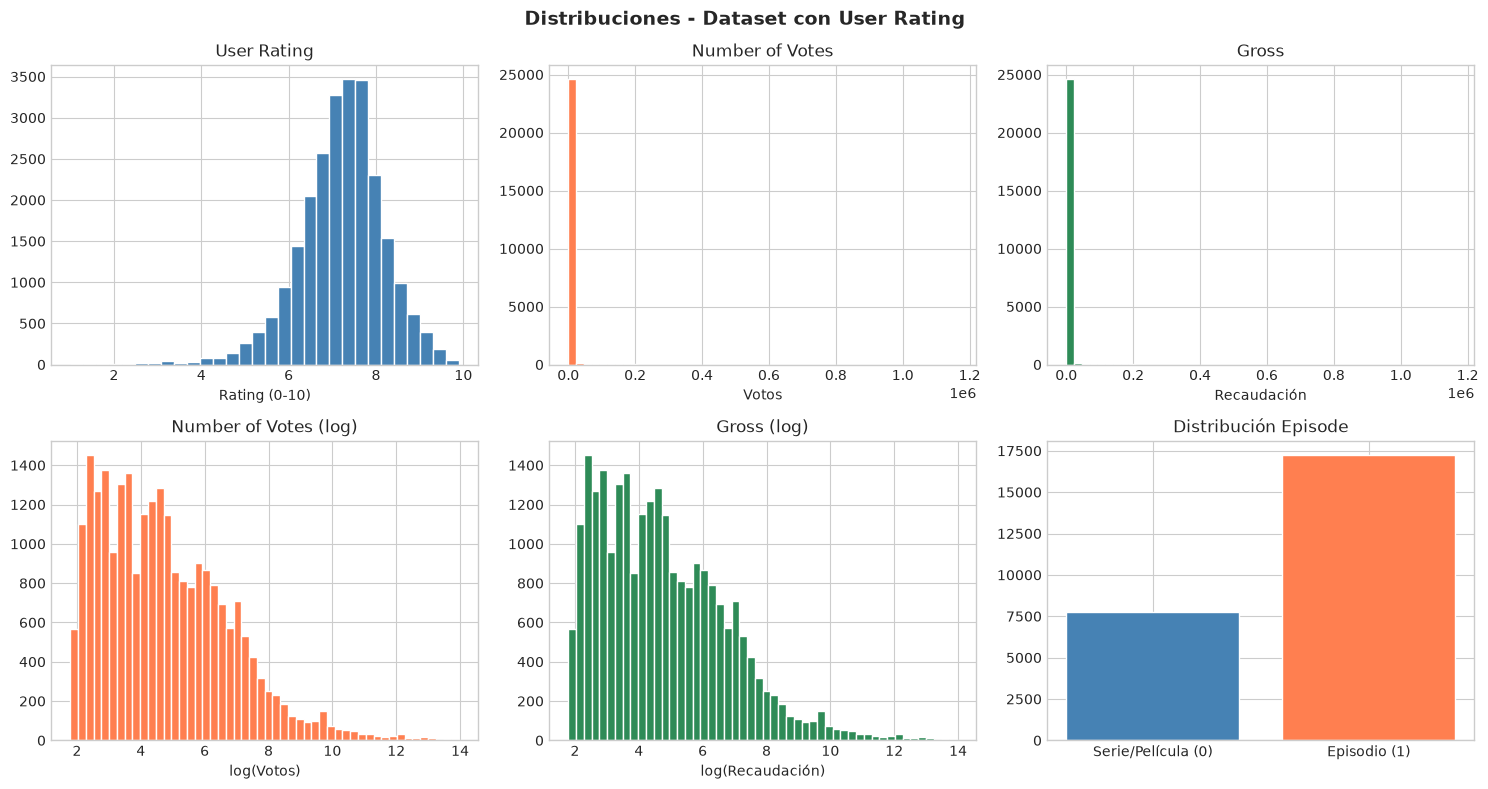

=== Estadísticas descriptivas ===


,User Rating,Number of Votes,Gross
count,25008.00,25008.00,25008.00
mean,7.22,2983.80,2983.80
std,1.00,31682.38,31682.38
min,1.00,5.00,5.00
25%,6.70,22.00,22.00
50%,7.30,84.00,84.00
75%,7.80,413.00,413.00
max,9.90,1162284.00,1162284.00


In [15]:
# Distribuciones de variables numéricas clave
df_base['User Rating'] = pd.to_numeric(df_base['User Rating'], errors='coerce')
df_base['Number of Votes'] = pd.to_numeric(df_base['Number of Votes'], errors='coerce')
df_base['Gross'] = pd.to_numeric(df_base['Gross'], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# User Rating
axes[0,0].hist(df_base['User Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('User Rating')
axes[0,0].set_xlabel('Rating (0-10)')

# Number of Votes
axes[0,1].hist(df_base['Number of Votes'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Number of Votes')
axes[0,1].set_xlabel('Votos')

# Gross
axes[0,2].hist(df_base['Gross'], bins=50, color='seagreen', edgecolor='white')
axes[0,2].set_title('Gross')
axes[0,2].set_xlabel('Recaudación')

# Number of Votes (log)
axes[1,0].hist(np.log1p(df_base['Number of Votes']), bins=50, color='coral', edgecolor='white')
axes[1,0].set_title('Number of Votes (log)')
axes[1,0].set_xlabel('log(Votos)')

# Gross (log)
axes[1,1].hist(np.log1p(df_base['Gross']), bins=50, color='seagreen', edgecolor='white')
axes[1,1].set_title('Gross (log)')
axes[1,1].set_xlabel('log(Recaudación)')

# Episode
axes[1,2].bar(['Serie/Película (0)', 'Episodio (1)'],
              df_base['Episode'].value_counts().sort_index().values,
              color=['steelblue', 'coral'], edgecolor='white')
axes[1,2].set_title('Distribución Episode')

plt.suptitle('Distribuciones - Dataset con User Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Estadísticas descriptivas ===')
df_base[['User Rating', 'Number of Votes', 'Gross']].describe().round(2)

In [16]:
# Confirmar que Gross = Number of Votes
print('¿Gross es igual a Number of Votes?')
print((df_base['Gross'] == df_base['Number of Votes']).all())

# Eliminar Gross por ser duplicado de Number of Votes
df_base = df_base.drop(columns=['Gross'])
print('Gross eliminado — era idéntico a Number of Votes')
print(f'Columnas restantes: {df_base.columns.tolist()}')

¿Gross es igual a Number of Votes?
True
Gross eliminado — era idéntico a Number of Votes
Columnas restantes: ['Title', 'Genre', 'User Rating', 'Number of Votes', 'Runtime', 'Year', 'Summary', 'Stars', 'Certificate', 'Metascore', 'Episode', 'Episode Title']


In [17]:
# ============================================================
# PUNTO 2: TRANSFORMACIÓN INICIAL DE DATOS
# ============================================================

# 1. User Rating — ya está numérico (lo convertimos antes)
# 2. Number of Votes — ya está numérico

# 3. Year — extraer el año numérico
# Ejemplos vistos: '(1999– )', -2023.0, '(2021)'
print('Ejemplos de Year:')
print(df_base['Year'].value_counts().head(10))

Ejemplos de Year:
Year
(1996– )       1019
(1997–2023)     990
(1999– )        919
(2007–2017)     503
(2021– )        417
(2012– )        416
(2000–2004)     393
(2016– )        353
(2017– )        352
(1989–1996)     326
Name: count, dtype: int64


Distribución de Year_num:
count    18913.000000
mean      2001.415217
std         12.148297
min       1934.000000
25%       1995.000000
50%       2000.000000
75%       2012.000000
max       2023.000000
Name: Year_num, dtype: float64

Nulos en Year_num: 6095



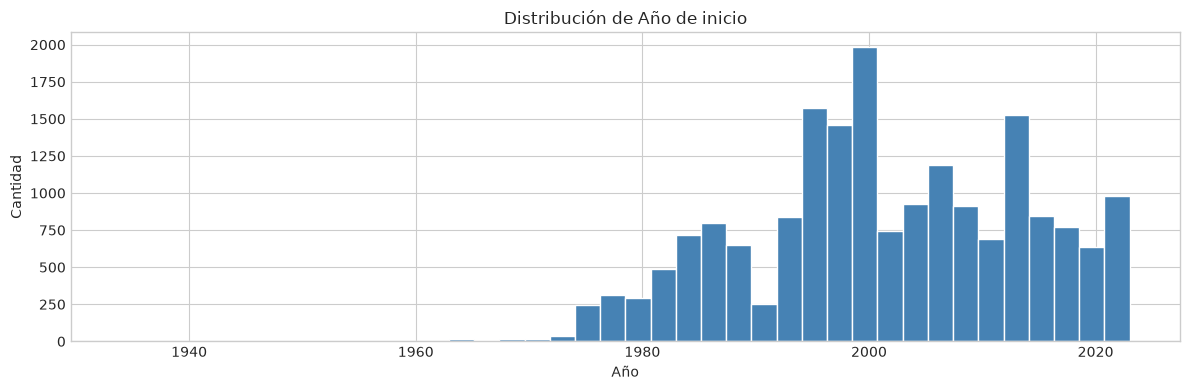

In [18]:
# Extraer año de inicio con regex
df_base['Year_num'] = df_base['Year'].str.extract(r'\((\d{4})')[0].astype(float)

print('Distribución de Year_num:')
print(df_base['Year_num'].describe())
print()
print(f'Nulos en Year_num: {df_base["Year_num"].isna().sum()}')
print()

# Visualizar distribución por décadas
plt.figure(figsize=(12, 4))
df_base['Year_num'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Distribución de Año de inicio')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [19]:
# ¿Por qué hay nulos en Year_num si Year tenía 0 nulos?
print('Valores de Year que no pudieron convertirse:')
mask_nulos = df_base['Year_num'].isna()
print(df_base[mask_nulos]['Year'].value_counts().head(15))

Valores de Year que no pudieron convertirse:
Year
-2017    316
-2018    310
-2016    304
-2007    279
-2011    276
-2006    266
-2012    240
-2010    218
-2014    213
-2008    211
-2015    205
-2005    205
-2009    204
-1998    176
-2019    172
Name: count, dtype: int64


In [20]:
# Los años negativos son años válidos con signo incorrecto
# Solución: para los nulos en Year_num, extraer el valor absoluto del año negativo
mask_nulos = df_base['Year_num'].isna()

df_base.loc[mask_nulos, 'Year_num'] = pd.to_numeric(
    df_base.loc[mask_nulos, 'Year'], errors='coerce'
).abs()

print(f'Nulos en Year_num después de corregir: {df_base["Year_num"].isna().sum()}')
print()
print('Distribución final:')
print(df_base['Year_num'].describe().round(0))

Nulos en Year_num después de corregir: 0

Distribución final:
count    25008.0
mean      2002.0
std         13.0
min       1907.0
25%       1996.0
50%       2003.0
75%       2012.0
max       2023.0
Name: Year_num, dtype: float64


In [21]:
# Ver formato de Runtime
print('Ejemplos de Runtime:')
print(df_base['Runtime'].value_counts().head(15))
print()
print(f'Nulos en Runtime: {df_base["Runtime"].isna().sum()}')

Ejemplos de Runtime:
Runtime
24 min    6340
25 min    3318
23 min    3227
22 min    1500
30 min     775
21 min     335
26 min     332
27 min     127
90 min     121
4 min      119
10 min      97
3 min       97
45 min      95
60 min      91
20 min      89
Name: count, dtype: int64

Nulos en Runtime: 5227


Nulos en Runtime_num: 5227

Distribución de Runtime_num:
count    19781.0
mean        31.5
std         30.2
min          1.0
25%         23.0
50%         24.0
75%         25.0
max        780.0
Name: Runtime_num, dtype: float64



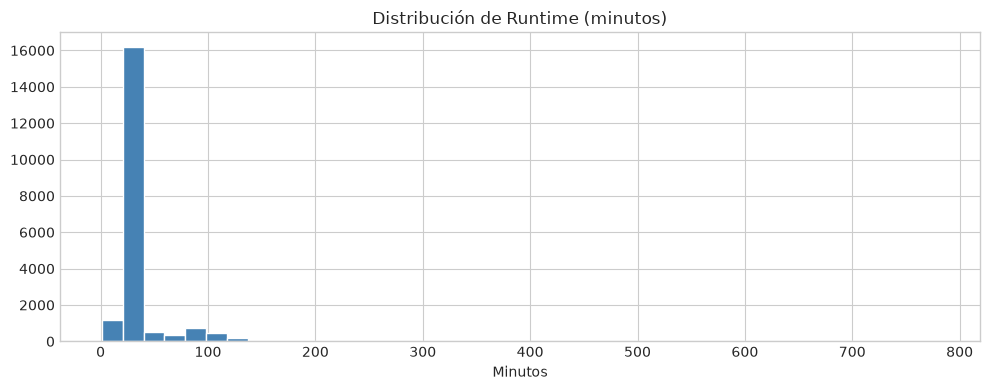

In [22]:
# Extraer minutos de Runtime
df_base['Runtime_num'] = df_base['Runtime'].str.extract(r'(\d+)').astype(float)

print(f'Nulos en Runtime_num: {df_base["Runtime_num"].isna().sum()}')
print()
print('Distribución de Runtime_num:')
print(df_base['Runtime_num'].describe().round(1))
print()

# Visualizar
plt.figure(figsize=(10, 4))
df_base['Runtime_num'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Distribución de Runtime (minutos)')
plt.xlabel('Minutos')
plt.tight_layout()
plt.show()

In [23]:
# Ver valores de Certificate
print('Valores únicos de Certificate:')
print(df_base['Certificate'].value_counts())
print()
print(f'Nulos en Certificate: {df_base["Certificate"].isna().sum()}')

Valores únicos de Certificate:
Certificate
TV-14        9362
TV-PG        2918
TV-MA        2712
TV-Y         1090
Not Rated    1062
TV-Y7         871
TV-Y7-FV      340
PG            241
TV-G          236
G             138
PG-13         116
15             94
Unrated        77
U              75
12             73
R              48
T              18
18             15
12A            14
M              10
X               6
TV-13           4
E10+            4
18+             3
16+             3
Approved        3
E               3
Banned          3
13+             2
Uc              1
R18             1
Open            1
Name: count, dtype: int64

Nulos en Certificate: 5464


In [24]:
# Agrupar Certificate en categorías estándar
cert_map = {
    # Para todos
    'TV-G': 'All', 'G': 'All', 'TV-Y': 'All', 'U': 'All', 'Uc': 'All', 'E': 'All', 'Open': 'All',
    # Niños 7+
    'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'E10+': 'Kids',
    # Todo público / Guía parental
    'TV-PG': 'PG', 'PG': 'PG', 'TV-13': 'PG', '12': 'PG', '12A': 'PG', '13+': 'PG',
    # Mayores de 14
    'TV-14': 'Teen', 'PG-13': 'Teen', 'T': 'Teen', '15': 'Teen', '16+': 'Teen', 'M': 'Teen',
    # Adultos
    'TV-MA': 'Adult', 'R': 'Adult', '18': 'Adult', '18+': 'Adult', 'R18': 'Adult', 'X': 'Adult',
    # Sin clasificar
    'Not Rated': 'Unrated', 'Unrated': 'Unrated', 'Approved': 'Unrated', 'Banned': 'Unrated'
}

df_base['Certificate_group'] = df_base['Certificate'].map(cert_map)

print('Distribución de Certificate agrupado:')
print(df_base['Certificate_group'].value_counts())
print()
print(f'Nulos en Certificate_group: {df_base["Certificate_group"].isna().sum()}')

Distribución de Certificate agrupado:
Certificate_group
Teen       9509
PG         3179
Adult      2770
All        1544
Kids       1215
Unrated    1145
Name: count, dtype: int64

Nulos en Certificate_group: 5646


In [25]:
# Ver qué valores de Certificate no quedaron mapeados
mask_no_mapeados = df_base['Certificate_group'].isna() & df_base['Certificate'].notna()
print('Valores no mapeados:')
print(df_base[mask_no_mapeados]['Certificate'].value_counts())

Valores no mapeados:
Certificate
15    94
12    73
18    15
Name: count, dtype: int64


In [26]:
# Agregar los valores faltantes al mapeo
cert_map_fix = {'15': 'Teen', '12': 'PG', '18': 'Adult'}
df_base['Certificate_group'] = df_base['Certificate_group'].fillna(
    df_base['Certificate'].map(cert_map_fix)
)

print('Distribución final de Certificate agrupado:')
print(df_base['Certificate_group'].value_counts())
print()
print(f'Nulos en Certificate_group: {df_base["Certificate_group"].isna().sum()}')

Distribución final de Certificate agrupado:
Certificate_group
Teen       9509
PG         3179
Adult      2770
All        1544
Kids       1215
Unrated    1145
Name: count, dtype: int64

Nulos en Certificate_group: 5646


In [27]:
# Reconstruir Certificate_group desde cero con el mapeo completo
cert_map_completo = {
    'TV-G': 'All', 'G': 'All', 'TV-Y': 'All', 'U': 'All', 'Uc': 'All', 'E': 'All', 'Open': 'All',
    'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'E10+': 'Kids',
    'TV-PG': 'PG', 'PG': 'PG', 'TV-13': 'PG', '12': 'PG', '12A': 'PG', '13+': 'PG',
    'TV-14': 'Teen', 'PG-13': 'Teen', 'T': 'Teen', '15': 'Teen', '16+': 'Teen', 'M': 'Teen',
    'TV-MA': 'Adult', 'R': 'Adult', '18': 'Adult', '18+': 'Adult', 'R18': 'Adult', 'X': 'Adult',
    'Not Rated': 'Unrated', 'Unrated': 'Unrated', 'Approved': 'Unrated', 'Banned': 'Unrated'
}

df_base['Certificate_group'] = df_base['Certificate'].map(cert_map_completo)

print('Distribución final de Certificate agrupado:')
print(df_base['Certificate_group'].value_counts())
print()
print(f'Nulos en Certificate_group: {df_base["Certificate_group"].isna().sum()}')

Distribución final de Certificate agrupado:
Certificate_group
Teen       9509
PG         3179
Adult      2770
All        1544
Kids       1215
Unrated    1145
Name: count, dtype: int64

Nulos en Certificate_group: 5646


In [28]:
# Extraer géneros con get_dummies
# El desafío sugiere este método específico:
genre_dummies = df_base['Genre'].str.split(', ').str.join('|').str.get_dummies()

print(f'Géneros encontrados ({len(genre_dummies.columns)}):')
print(genre_dummies.columns.tolist())
print()
print('Top 10 géneros más frecuentes:')
print(genre_dummies.sum().sort_values(ascending=False).head(10))

Géneros encontrados (22):
['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War']

Top 10 géneros más frecuentes:
Animation    25005
Action       15597
Adventure    12594
Comedy        7184
Drama         5430
Fantasy       1470
Short         1368
Romance        808
Sci-Fi         692
Family         684
dtype: int64


In [29]:
# Agregar genre dummies al dataset
df_base = pd.concat([df_base, genre_dummies], axis=1)

print(f'Dimensiones después de agregar géneros: {df_base.shape}')
print(f'Nuevas columnas de género agregadas: {len(genre_dummies.columns)}')

Dimensiones después de agregar géneros: (25008, 37)
Nuevas columnas de género agregadas: 22


In [30]:
# Análisis rápido de Stars
print(f'Registros con Stars: {df_base["Stars"].notna().sum()} ({df_base["Stars"].notna().mean()*100:.1f}%)')
print()

# Top estrellas más frecuentes
stars_series = df_base['Stars'].dropna().str.split(',').explode().str.strip()
print('Top 15 estrellas más frecuentes:')
print(stars_series.value_counts().head(15))

Registros con Stars: 8058 (32.2%)

Top 15 estrellas más frecuentes:
Stars
Tony Beck           280
Dan Green           245
Rie Kugimiya        234
Wayne Grayson       227
Tetsuya Kakihara    217
Mayumi Tanaka       207
Yûko Sanpei         193
Aya Hirano          187
Hiroaki Hirata      186
Tia Lynn Ballard    173
Chô                 171
Luci Christian      167
Amy Birnbaum        167
Hiroshi Kamiya      165
Gregory Abbey       158
Name: count, dtype: int64


In [31]:
# Documentar decisión y eliminar Stars del análisis
# Stars tiene 67.8% de nulos — no es recuperable sin introducir sesgo
# Las frecuencias más altas (280 apariciones de 25,008 registros = 1.1%)
# son demasiado bajas para generar dummies útiles

df_base = df_base.drop(columns=['Stars'])
print(f'Stars eliminado del análisis')
print(f'Dimensiones actuales: {df_base.shape}')
print(f'Columnas: {[c for c in df_base.columns if c not in genre_dummies.columns]}')

Stars eliminado del análisis
Dimensiones actuales: (25008, 36)
Columnas: ['Title', 'Genre', 'User Rating', 'Number of Votes', 'Runtime', 'Year', 'Summary', 'Certificate', 'Metascore', 'Episode', 'Episode Title', 'Year_num', 'Runtime_num', 'Certificate_group']


In [32]:
# Detección de outliers con IQR en variables numéricas clave
def detectar_outliers_iqr(df, columna, factor=1.5):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - factor * IQR
    limite_sup = Q3 + factor * IQR
    outliers = df[(df[columna] < limite_inf) | (df[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

print('=== Resumen de Outliers (IQR, factor=1.5) ===\n')
for col in ['User Rating', 'Number of Votes', 'Runtime_num', 'Year_num']:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df_base.dropna(subset=[col]), col)
    print(f'{col}:')
    print(f'  Rango válido: [{lim_inf:.1f}, {lim_sup:.1f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(df_base)*100:.1f}%)')
    print()

=== Resumen de Outliers (IQR, factor=1.5) ===

User Rating:
  Rango válido: [5.1, 9.4]
  Outliers: 822 (3.3%)

Number of Votes:
  Rango válido: [-564.5, 999.5]
  Outliers: 3670 (14.7%)

Runtime_num:
  Rango válido: [20.0, 28.0]
  Outliers: 4436 (17.7%)

Year_num:
  Rango válido: [1972.0, 2036.0]
  Outliers: 279 (1.1%)



In [33]:
# Ver años futuros y muy antiguos
print('Años > 2024:')
print(df_base[df_base['Year_num'] > 2024]['Year_num'].value_counts())
print()
print('Años < 1950:')
print(df_base[df_base['Year_num'] < 1950]['Year_num'].value_counts())


Años > 2024:
Series([], Name: count, dtype: int64)

Años < 1950:
Year_num
1931.0    19
1936.0    11
1935.0    10
1934.0    10
1932.0     8
1917.0     6
1929.0     5
1928.0     5
1930.0     5
1933.0     5
1925.0     4
1926.0     4
1924.0     4
1941.0     3
1942.0     3
1927.0     3
1946.0     3
1939.0     3
1948.0     3
1918.0     2
1945.0     1
1907.0     1
1943.0     1
1938.0     1
1949.0     1
1937.0     1
1947.0     1
1940.0     1
Name: count, dtype: int64


In [34]:
# ============================================================
# PUNTO 4: TRANSFORMACIÓN DE VARIABLES FINALES
# ============================================================

# 1. Number of Votes — transformación logarítmica
df_base['votes_log'] = np.log1p(df_base['Number of Votes'])

# 2. Runtime — agrupar en rangos
def clasificar_runtime(mins):
    if pd.isna(mins): return np.nan
    if mins <= 5: return 'Short'        # cortometrajes
    if mins <= 30: return 'Episode'     # episodios TV típicos
    if mins <= 60: return 'Medium'      # episodios largos
    if mins <= 120: return 'Movie'      # películas
    return 'Long'                        # contenido muy largo

df_base['Runtime_cat'] = df_base['Runtime_num'].apply(clasificar_runtime)
print('Distribución Runtime_cat:')
print(df_base['Runtime_cat'].value_counts())

Distribución Runtime_cat:
Runtime_cat
Episode    16865
Movie       1566
Medium       699
Short        441
Long         210
Name: count, dtype: int64


In [35]:
# 3. Year — agrupar en décadas
def clasificar_decada(year):
    if pd.isna(year): return np.nan
    if year < 1980: return 'Pre-1980'
    if year < 1990: return '1980s'
    if year < 2000: return '1990s'
    if year < 2010: return '2000s'
    if year < 2020: return '2010s'
    return '2020s'

df_base['Decade'] = df_base['Year_num'].apply(clasificar_decada)
print('\nDistribución por Década:')
print(df_base['Decade'].value_counts().sort_index())


Distribución por Década:
Decade
1980s       3218
1990s       6132
2000s       6024
2010s       6646
2020s       1686
Pre-1980    1302
Name: count, dtype: int64


In [36]:
# 4. Estrategia para nulos restantes
print('\n=== Nulos restantes en variables clave ===')
vars_clave = ['User Rating', 'votes_log', 'Runtime_cat', 'Year_num', 'Certificate_group', 'Decade']
print(df_base[vars_clave].isnull().sum())


=== Nulos restantes en variables clave ===
User Rating             0
votes_log               0
Runtime_cat          5227
Year_num                0
Certificate_group    5646
Decade                  0
dtype: int64


In [37]:
# ============================================================
# ESTRATEGIA PARA NULOS
# ============================================================

# Runtime_cat: imputar con 'Unknown' — no podemos inferir duración
# Certificate_group: imputar con 'Unrated' — sin clasificación conocida

df_base['Runtime_cat'] = df_base['Runtime_cat'].fillna('Unknown')
df_base['Certificate_group'] = df_base['Certificate_group'].fillna('Unrated')

print('Nulos después de imputar:')
print(df_base[['Runtime_cat', 'Certificate_group']].isnull().sum())
print()
print('Distribución Runtime_cat final:')
print(df_base['Runtime_cat'].value_counts())
print()
print('Distribución Certificate_group final:')
print(df_base['Certificate_group'].value_counts())

Nulos después de imputar:
Runtime_cat          0
Certificate_group    0
dtype: int64

Distribución Runtime_cat final:
Runtime_cat
Episode    16865
Unknown     5227
Movie       1566
Medium       699
Short        441
Long         210
Name: count, dtype: int64

Distribución Certificate_group final:
Certificate_group
Teen       9509
Unrated    6791
PG         3179
Adult      2770
All        1544
Kids       1215
Name: count, dtype: int64


In [38]:
# Get dummies para Certificate_group, Runtime_cat y Decade
cert_dummies = pd.get_dummies(df_base['Certificate_group'], prefix='cert')
runtime_dummies = pd.get_dummies(df_base['Runtime_cat'], prefix='runtime')
decade_dummies = pd.get_dummies(df_base['Decade'], prefix='decade')

# Agregar al dataset
df_base = pd.concat([df_base, cert_dummies, runtime_dummies, decade_dummies], axis=1)

print(f'Dimensiones finales: {df_base.shape}')
print(f'\nNuevas columnas agregadas:')
print('Certificate:', cert_dummies.columns.tolist())
print('Runtime:', runtime_dummies.columns.tolist())
print('Decade:', decade_dummies.columns.tolist())

Dimensiones finales: (25008, 57)

Nuevas columnas agregadas:
Certificate: ['cert_Adult', 'cert_All', 'cert_Kids', 'cert_PG', 'cert_Teen', 'cert_Unrated']
Runtime: ['runtime_Episode', 'runtime_Long', 'runtime_Medium', 'runtime_Movie', 'runtime_Short', 'runtime_Unknown']
Decade: ['decade_1980s', 'decade_1990s', 'decade_2000s', 'decade_2010s', 'decade_2020s', 'decade_Pre-1980']
